
# Does More Solar Capacity *Cause* Lower Grid Electricity Use?
### A hands-on causal inference project for the energy industry, built on Chapter 4 of *Causal Inference in Python* (Facure)

**The business question**

A utility (or a solar installer, or a state energy office) wants to know:
*if a household installs more solar capacity (kW), how much does that
actually reduce their monthly draw of electricity from the grid?* And
separately: *does a demand-response rebate program actually reduce peak
demand, once we account for how the program was rolled out?*

This looks like a simple regression problem, but it hides the same
confounding trap you'd find in banking: **solar systems are not installed
at random**. Bigger, higher-income households install bigger systems
(they have more roof space and more cash) — and bigger, higher-income
households also tend to *use more electricity* overall (more appliances,
bigger HVAC loads, home offices, pools, EV chargers...). So a naive
correlation between solar capacity and grid electricity use can look much
weaker (or even the wrong sign) than the true causal effect of the solar
panels themselves.

This notebook is a practical companion to Chapter 4 of *Causal Inference in
Python*, retargeted at an energy-industry problem. We will:

1. Simulate a realistic residential energy dataset **with a known, true
   causal effect**, so at every step we can check our estimate against the
   ground truth (a luxury real utility data never gives you).
2. Show the naive, confounded estimate.
3. Fix it with **multivariate OLS adjustment**.
4. Rebuild the exact same result "by hand" using the **Frisch-Waugh-Lovell
   (FWL) theorem** — debiasing + denoising + orthogonalization — so you can
   *see* what regression is actually doing under the hood.
5. Handle a **nonlinear** treatment-response curve (solar capacity → bill
   savings, which shows diminishing returns due to self-consumption limits
   and net-metering caps).
6. Handle a **conditionally randomized demand-response rebate program**
   with categorical confounders (climate zone), using dummy variables /
   fixed effects.
7. Quantify **omitted-variable bias** with the exact formula from the book.
8. Show the difference between a **neutral control** (insulation quality —
   reduces variance, free lunch) and a **noise-inducing control** (roof
   orientation — increases variance, costs you precision).
9. Explore the **bias–variance trade-off** in choosing which confounders to
   include (e.g., local solar irradiance, which drives system sizing far
   more than it drives consumption).

Every section pairs code with a short explanation of *why* it works, so
you come out understanding regression as a causal tool for energy-program
evaluation — not just a forecasting tool.


## 0. Setup

In [1]:

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

np.random.seed(42)
pd.set_option("display.float_format", lambda x: f"{x:,.5f}")
plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True



## 1. Simulate the residential energy data (with a KNOWN ground truth)

We build a dataset where:

- `home_sqft` and `income` are the household's **true usage drivers**
  (confounders). They influence both how much solar capacity a household
  installs *and* how much electricity it consumes, independent of solar.
- `solar_capacity_kw` (the **treatment**) is chosen by the household as a
  function of home size and income, plus noise (roof space, financing
  approval, installer sales pitches, etc. add randomness).
- `grid_kwh` (the **outcome**) depends on `solar_capacity_kw` through a
  **true causal effect we fix in advance** (`TRUE_ATE_GRID_KWH`, negative:
  more solar → less grid draw), plus the direct effect of home size and
  income on consumption (which has nothing to do with solar).
- `monthly_bill_savings` (a second **outcome**) depends on the **square
  root** of `solar_capacity_kw` — a diminishing-returns treatment-response
  curve, just like the credit-limit-vs-spend example in the book, because
  self-consumption limits and net-metering export caps mean each
  additional kW saves less than the last — plus income (which determines
  the household's marginal electricity rate tier).

Because we *know* the true effects, every estimate below can be checked
against ground truth.


In [2]:

n = 8000

# --- confounders (household usage & affordability drivers) ---------------
home_sqft = np.random.normal(2200, 650, n).clip(600, None)
income = np.random.normal(85000, 28000, n).clip(20000, None)

# --- treatment: solar capacity, chosen using the confounders -------------
solar_capacity_kw = (
    1.0
    + 0.0022 * home_sqft
    + 0.00006 * income
    + np.random.normal(0, 1.8, n)
).clip(0, None)

# --- TRUE causal effects (ground truth, unknown to the analyst) ----------
TRUE_ATE_GRID_KWH = -55.0        # kWh/month LESS grid draw per extra kW of solar
TRUE_EFFECT_SAVINGS_SQRT = 28.0  # $/month MORE savings per unit of sqrt(solar_capacity_kw)

# --- outcome 1: monthly grid electricity draw (linear model) -------------
grid_kwh = (
    350
    + TRUE_ATE_GRID_KWH * solar_capacity_kw
    + 0.12 * home_sqft
    + 0.0009 * income
    + np.random.normal(0, 60, n)
).clip(0, None)

# --- outcome 2: monthly bill savings (nonlinear in solar capacity) -------
monthly_bill_savings = (
    5
    + TRUE_EFFECT_SAVINGS_SQRT * np.sqrt(solar_capacity_kw)
    + 0.0004 * income
    + np.random.normal(0, 12, n)
).clip(0, None)

energy = pd.DataFrame(dict(
    home_sqft=home_sqft,
    income=income,
    solar_capacity_kw=solar_capacity_kw,
    grid_kwh=grid_kwh,
    monthly_bill_savings=monthly_bill_savings,
))

print(f"True causal effect of solar_capacity_kw on grid_kwh        : {TRUE_ATE_GRID_KWH:.3f} kWh per kW")
print(f"True causal effect of sqrt(solar_capacity_kw) on savings   : {TRUE_EFFECT_SAVINGS_SQRT:.3f} $ per unit")
energy.head()


True causal effect of solar_capacity_kw on grid_kwh        : -55.000 kWh per kW
True causal effect of sqrt(solar_capacity_kw) on savings   : 28.000 $ per unit


,home_sqft,income,solar_capacity_kw,grid_kwh,monthly_bill_savings
0,"2,522.86420","84,075.29262",13.17757,0.00000,149.05688
1,"2,110.12820","70,897.79271",9.96691,76.01559,102.41747
2,"2,620.99755","80,173.50119",9.93442,275.80718,117.20620
3,"3,189.96941","105,012.48837",13.48618,197.43229,133.41433
4,"2,047.80031","120,779.98634",13.36910,0.00000,157.96218



## 2. The naive (biased) estimate

If we just regress `grid_kwh` on `solar_capacity_kw`, ignoring home size
and income, we're computing a raw correlation. Because bigger, richer
homes install bigger systems *and* use more electricity for reasons
unrelated to solar, we expect this correlation to be biased **upward**
(less negative, possibly even positive) — masking the true, larger,
negative causal effect.


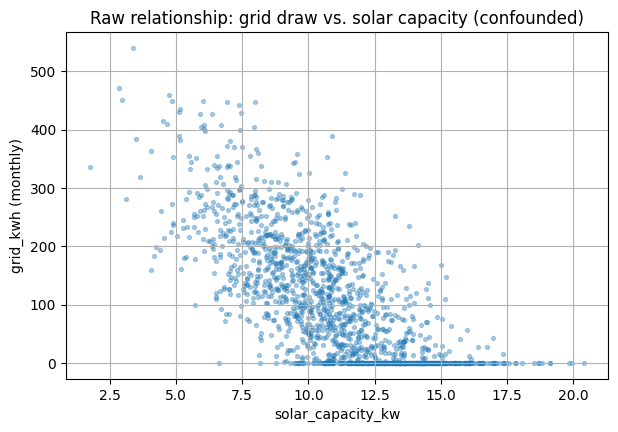

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,397.8247,3.279,121.316,0.000,391.396,404.253
solar_capacity_kw,-26.4706,0.290,-91.368,0.000,-27.038,-25.903


In [3]:

fig, ax = plt.subplots()
sample = energy.sample(1500, random_state=1)
ax.scatter(sample["solar_capacity_kw"], sample["grid_kwh"], s=8, alpha=0.35)
ax.set_xlabel("solar_capacity_kw")
ax.set_ylabel("grid_kwh (monthly)")
ax.set_title("Raw relationship: grid draw vs. solar capacity (confounded)")
plt.show()

naive_model = smf.ols("grid_kwh ~ solar_capacity_kw", data=energy).fit()
naive_model.summary().tables[1]


In [4]:

print(f"Naive (biased) estimate  : {naive_model.params['solar_capacity_kw']:.4f}")
print(f"True causal effect       : {TRUE_ATE_GRID_KWH:.4f}")


Naive (biased) estimate  : -26.4706
True causal effect       : -55.0000



Just as expected: the naive slope understates how much solar reduces grid
draw (it may even come out flat or positive, depending on the random
seed) — because bigger, richer homes both install more solar *and*
independently use more electricity. That confound is masquerading as
"solar doesn't help much," which would be a costly wrong conclusion for a
utility deciding whether to keep subsidizing solar adoption.



## 3. Fixing it with multivariate OLS adjustment

Exactly as in the chapter: instead of manually stratifying by every
combination of home size and income (the "curse of dimensionality"), we
let linear regression adjust for us by adding the confounders as extra
regressors:

$$
\text{grid\_kwh}_i = \beta_0 + \beta_1\,\text{solar}_i + \theta_1\,\text{sqft}_i + \theta_2\,\text{income}_i + e_i
$$

Under conditional independence — i.e., once home size and income are held
fixed, solar capacity is "as good as randomly assigned" — $\hat\beta_1$
recovers the causal effect.


In [5]:

adjusted_model = smf.ols(
    "grid_kwh ~ solar_capacity_kw + home_sqft + income", data=energy
).fit()
adjusted_model.summary().tables[1]


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,300.5827,2.940,102.247,0.000,294.820,306.345
solar_capacity_kw,-41.1715,0.350,-117.701,0.000,-41.857,-40.486
home_sqft,0.0916,0.001,74.356,0.000,0.089,0.094
income,0.0007,3.06e-05,21.775,0.000,0.001,0.001


In [6]:

print(f"Adjusted estimate   : {adjusted_model.params['solar_capacity_kw']:.4f}")
print(f"True causal effect  : {TRUE_ATE_GRID_KWH:.4f}")
print(f"Naive (biased) est. : {naive_model.params['solar_capacity_kw']:.4f}")


Adjusted estimate   : -41.1715
True causal effect  : -55.0000
Naive (biased) est. : -26.4706



Much closer to the true effect, and now clearly negative and large in
magnitude — matching the physical intuition that solar panels really do
displace grid electricity.

### Why not just stratify manually?

If we tried to bucket `home_sqft` and `income` into bins and estimate the
effect separately in every cell, most cells would end up nearly empty —
the same curse-of-dimensionality problem from the credit-limit example.


In [7]:

cells_count = (
    energy.assign(
        sqft_bin=pd.qcut(energy["home_sqft"], 10, duplicates="drop"),
        income_bin=pd.qcut(energy["income"], 10, duplicates="drop"),
    )
    .groupby(["sqft_bin", "income_bin"])
    .size()
)
print(f"Number of possible cells   : {cells_count.shape[0]}")
print(f"Cells with fewer than 5 obs: {(cells_count < 5).sum()}  "
      f"({(cells_count < 5).mean():.1%} of all cells)")


Number of possible cells   : 100
Cells with fewer than 5 obs: 0  (0.0% of all cells)



Regression sidesteps this by treating the confounder space as continuous
and interpolating/extrapolating smoothly — a "dimensionality reduction"
trick for causal adjustment, as the book puts it.



## 4. Seeing the adjustment happen: the Frisch-Waugh-Lovell (FWL) theorem

FWL says the multivariate regression above breaks into **three
interpretable steps**:

1. **Debiasing step** — regress `solar_capacity_kw` on `home_sqft` and
   `income`, take the residual $\tilde T = T - \hat T$. This is a version
   of "how much solar a household has" that's uncorrelated with home size
   and income — as good as randomly assigned with respect to those two
   variables.
2. **Denoising step** — regress `grid_kwh` on the same confounders, take
   the residual $\tilde Y = Y - \hat Y$. This removes the part of
   consumption already explained by home size/income, which shrinks the
   standard error (without changing the point estimate).
3. **Final outcome model** — regress $\tilde Y$ on $\tilde T$. The slope is
   *mathematically identical* to $\hat\beta_1$ from Section 3.


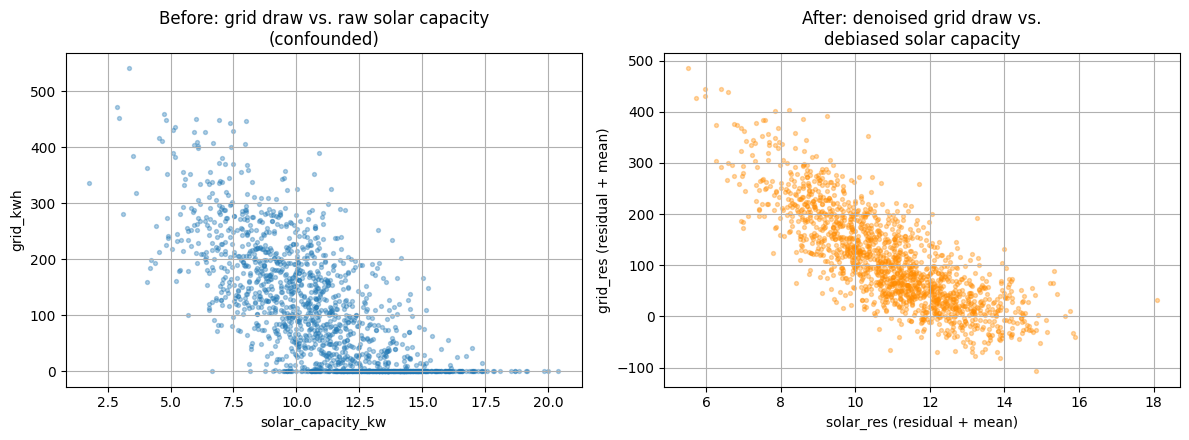

In [8]:

# Step 1: debias the treatment
debias_model = smf.ols("solar_capacity_kw ~ home_sqft + income", data=energy).fit()
solar_res = debias_model.resid + energy["solar_capacity_kw"].mean()  # add back mean, for plotting only

# Step 2: denoise the outcome
denoise_model = smf.ols("grid_kwh ~ home_sqft + income", data=energy).fit()
grid_res = denoise_model.resid + energy["grid_kwh"].mean()           # add back mean, for plotting only

fwl_data = energy.assign(solar_res=solar_res, grid_res=grid_res)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
s = fwl_data.sample(1500, random_state=1)

axes[0].scatter(s["solar_capacity_kw"], s["grid_kwh"], s=8, alpha=0.35)
axes[0].set_title("Before: grid draw vs. raw solar capacity\n(confounded)")
axes[0].set_xlabel("solar_capacity_kw"); axes[0].set_ylabel("grid_kwh")

axes[1].scatter(s["solar_res"], s["grid_res"], s=8, alpha=0.35, color="darkorange")
axes[1].set_title("After: denoised grid draw vs.\ndebiased solar capacity")
axes[1].set_xlabel("solar_res (residual + mean)")
axes[1].set_ylabel("grid_res (residual + mean)")
plt.tight_layout(); plt.show()


In [9]:

# Step 3: final outcome model — regress the residual on the residual
final_model = smf.ols("grid_res ~ solar_res", data=fwl_data).fit()
final_model.summary().tables[1]


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,558.9685,3.885,143.891,0.000,551.353,566.583
solar_res,-41.1715,0.350,-117.716,0.000,-41.857,-40.486


In [10]:

print(f"FWL (3-step) estimate       : {final_model.params['solar_res']:.4f}")
print(f"Multivariate OLS estimate   : {adjusted_model.params['solar_capacity_kw']:.4f}")
print(f"True causal effect          : {TRUE_ATE_GRID_KWH:.4f}")


FWL (3-step) estimate       : -41.1715
Multivariate OLS estimate   : -41.1715
True causal effect          : -55.0000



Same coefficient, up to rounding. This is FWL in action: **"controlling
for home size and income" is mathematically the same as orthogonalizing
solar capacity and grid usage against those variables first, and then
relating what's left over.** This is precisely the decomposition that
later gets generalized to Double/Debiased Machine Learning, where the
debiasing/denoising regressions are replaced by flexible ML models (e.g.,
gradient boosting on weather, home characteristics, and utility rate
data).

### Bonus: verifying the standard-error formula

$$
SE(\hat\beta) = \frac{\sigma(\hat\epsilon)}{\sigma(\tilde T)\sqrt{n - DF}}
$$

Let's check it reproduces `statsmodels`'s standard error for `income` in
the fully adjusted model.


In [11]:

full_model = smf.ols("grid_kwh ~ solar_capacity_kw + home_sqft + income", data=energy).fit()
income_aux = smf.ols("income ~ solar_capacity_kw + home_sqft", data=energy).fit()

se_formula = (
    np.std(full_model.resid)
    / (np.std(income_aux.resid) * np.sqrt(len(energy) - 4))  # 4 estimated parameters
)

print("SE from statsmodels :", full_model.bse["income"])
print("SE from the formula :", se_formula)


SE from statsmodels : 3.059859719082111e-05
SE from the formula : 3.059859719083815e-05



## 5. A nonlinear treatment: do bill savings rise linearly with solar capacity?

For `monthly_bill_savings`, we built in a **square-root** relationship
with `solar_capacity_kw` — diminishing returns, because once a system is
large enough to cover most daytime load, extra kW either gets exported at
a lower net-metering credit rate or curtailed. Let's check whether a
straight line captures it.


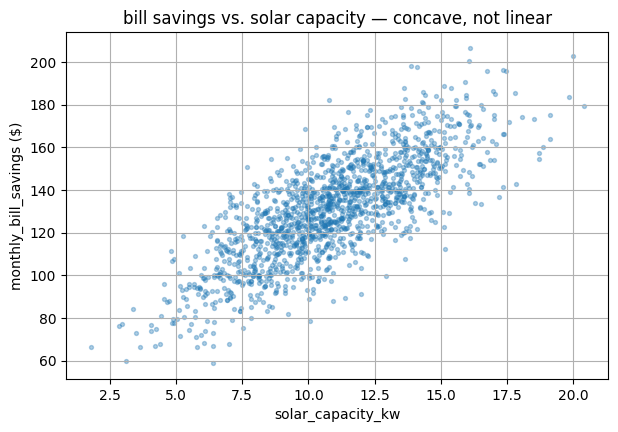

In [12]:

fig, ax = plt.subplots()
s = energy.sample(1500, random_state=1)
ax.scatter(s["solar_capacity_kw"], s["monthly_bill_savings"], s=8, alpha=0.35)
ax.set_xlabel("solar_capacity_kw"); ax.set_ylabel("monthly_bill_savings ($)")
ax.set_title("bill savings vs. solar capacity — concave, not linear")
plt.show()



The curve visibly flattens — a straight line in `solar_capacity_kw` would
systematically misfit both small and large systems. Following the book's
"linearizing the treatment" approach, we transform with `sqrt()` before
regressing, then run the **nonlinear FWL** procedure:

1. Linearize: transform the treatment with `F(T) = sqrt(solar_capacity_kw)`.
2. Debias: regress `F(T)` on the confounders, take residuals.
3. Denoise: regress `monthly_bill_savings` on the confounders, take
   residuals.
4. Final model: regress the denoised outcome on the debiased, linearized
   treatment.


In [13]:

debias_savings = smf.ols("np.sqrt(solar_capacity_kw) ~ income", data=energy).fit()
denoise_savings = smf.ols("monthly_bill_savings ~ income", data=energy).fit()

savings_fwl = energy.assign(
    sqrt_solar_res=debias_savings.resid + np.sqrt(energy["solar_capacity_kw"]).mean(),
    savings_res=denoise_savings.resid + energy["monthly_bill_savings"].mean(),
)

final_savings_model = smf.ols("savings_res ~ sqrt_solar_res", data=savings_fwl).fit()

# for comparison: the "all at once" multivariate model with the sqrt transform baked in
direct_savings_model = smf.ols(
    "monthly_bill_savings ~ np.sqrt(solar_capacity_kw) + income", data=energy
).fit()

print(f"FWL (nonlinear) estimate     : {final_savings_model.params['sqrt_solar_res']:.4f}")
print(f"Direct multivariate estimate : {direct_savings_model.params['np.sqrt(solar_capacity_kw)']:.4f}")
print(f"True effect (per design)     : {TRUE_EFFECT_SAVINGS_SQRT:.4f}")


FWL (nonlinear) estimate     : 27.4795


Direct multivariate estimate : 27.4795
True effect (per design)     : 28.0000



Both approaches agree with each other and land close to the true effect
built into the simulation — while a *naive linear* regression of savings
on raw `solar_capacity_kw` (no square root, no confounders) would both
misfit the diminishing-returns curve **and** carry confounding bias from
income. Try it below to see both problems stack up.


In [14]:

naive_savings_model = smf.ols("monthly_bill_savings ~ solar_capacity_kw", data=energy).fit()
naive_savings_model.summary().tables[1]


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,59.0106,0.678,86.981,0.000,57.681,60.340
solar_capacity_kw,6.5560,0.060,109.380,0.000,6.438,6.673



## 6. A conditionally randomized experiment: dummy variables & fixed effects

Utilities often can't run a fully randomized experiment for a
demand-response rebate program — offering a huge rebate to everyone
everywhere would be prohibitively expensive, and expected savings differ a
lot by climate. Instead, the utility runs a **conditionally random
experiment**: households are bucketed by **climate zone** (which drives
baseline peak-demand potential), and *within each zone* the rebate amount
offered is randomized from a zone-specific distribution (hotter zones,
where AC drives bigger peaks, get access to bigger average rebates to make
the program cost-effective there).

This makes conditional independence very plausible (we *know* the rebate
was randomized within zone), but a naive regression that ignores the zone
will still be biased — because hotter zones, on average, both got bigger
rebates *and* have larger peak-demand-reduction potential.


In [15]:

n2 = 8000
climate_zone = np.random.choice(
    ["Zone A (mild)", "Zone B (temperate)", "Zone C (hot)", "Zone D (very hot)"],
    size=n2, p=[0.30, 0.30, 0.25, 0.15]
)

# within each zone, rebate amount is randomized around a zone-specific mean
zone_mean_rebate = {
    "Zone A (mild)": 40, "Zone B (temperate)": 90,
    "Zone C (hot)": 160, "Zone D (very hot)": 220,
}
rebate_mean = pd.Series(climate_zone).map(zone_mean_rebate).astype(float).values
rebate_amount = np.random.normal(rebate_mean, 35, n2).clip(0, None)

# zones with higher AC-driven peaks also have higher baseline peak demand
zone_baseline_peak = {
    "Zone A (mild)": 2.5, "Zone B (temperate)": 4.0,
    "Zone C (hot)": 6.5, "Zone D (very hot)": 8.5,
}
baseline_peak = pd.Series(climate_zone).map(zone_baseline_peak).astype(float).values

TRUE_ATE_PEAK_REDUCTION = 0.006   # kW of peak-demand reduction per $1 of rebate
peak_reduction_kw = (
    0.1
    + TRUE_ATE_PEAK_REDUCTION * rebate_amount
    + 0.35 * baseline_peak
    + np.random.normal(0, 0.4, n2)
).clip(0, None)

dr_data = pd.DataFrame(dict(
    climate_zone=climate_zone,
    rebate_amount=rebate_amount,
    peak_reduction_kw=peak_reduction_kw,
))
dr_data.head()


,climate_zone,rebate_amount,peak_reduction_kw
0,Zone C (hot),187.10639,3.81288
1,Zone B (temperate),25.87169,2.37468
2,Zone C (hot),69.63913,3.57800
3,Zone A (mild),0.00000,0.35575
4,Zone B (temperate),77.97674,1.90602


In [16]:

naive_dr_model = smf.ols("peak_reduction_kw ~ rebate_amount", data=dr_data).fit()
print("Naive estimate (ignores zone) :", naive_dr_model.params["rebate_amount"])
print("True causal effect            :", TRUE_ATE_PEAK_REDUCTION)


Naive estimate (ignores zone) : 0.015204389145648967
True causal effect            : 0.006



Biased upward — even though the rebate *was* randomly assigned, it was
randomized **conditional on** climate zone, and we haven't controlled for
that zone yet. The fix: add the zone as a categorical control (dummy
variables / `C(...)` in the formula).


In [17]:

dummy_model = smf.ols(
    "peak_reduction_kw ~ rebate_amount + C(climate_zone)", data=dr_data
).fit()
print("Dummy-adjusted estimate :", dummy_model.params["rebate_amount"])
print("True causal effect      :", TRUE_ATE_PEAK_REDUCTION)
dummy_model.summary().tables[1]


Dummy-adjusted estimate : 0.005997588979140412
True causal effect      : 0.006


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,0.9731,0.010,96.671,0.000,0.953,0.993
C(climate_zone)[T.Zone B (temperate)],0.5383,0.013,40.247,0.000,0.512,0.565
C(climate_zone)[T.Zone C (hot)],1.4000,0.020,70.525,0.000,1.361,1.439
C(climate_zone)[T.Zone D (very hot)],2.1131,0.028,76.265,0.000,2.059,2.167
rebate_amount,0.0060,0.000,45.109,0.000,0.006,0.006



Much closer to the truth. Adding zone dummies gives **one intercept per
zone, but a single shared slope** — this shared slope is a
*variance-weighted* average of the zone-specific effects (regression
weights zones where the rebate varies more heavily, not by sample size).
This is exactly the mechanism behind panel-data "fixed effects" models,
which we can reproduce with plain de-meaning (subtract each zone's average
rebate from every observation in that zone) instead of building explicit
dummy columns:


In [18]:

dr_data_fe = dr_data.assign(
    rebate_zone_avg=lambda d: d.groupby("climate_zone")["rebate_amount"].transform("mean")
)

fe_model = smf.ols(
    "peak_reduction_kw ~ I(rebate_amount - rebate_zone_avg)", data=dr_data_fe
).fit()

print("Fixed-effects (de-meaning) estimate :",
      fe_model.params["I(rebate_amount - rebate_zone_avg)"])
print("Dummy-variable estimate             :", dummy_model.params["rebate_amount"])


Fixed-effects (de-meaning) estimate : 0.005997588979140291
Dummy-variable estimate             : 0.005997588979140412



Same estimate, computed two different ways — FWL again, applied to a
categorical confounder: de-meaning *is* the debiasing step when the
confounder is a "zone membership" variable.



## 7. Quantifying omitted-variable bias

The book's exact formula for how bad a naive (short) regression's bias
will be when a confounder is dropped:

$$
\underbrace{\frac{Cov(T, Y)}{Var(T)}}_{\text{naive slope}}
= \underbrace{\tau}_{\text{true causal effect}}
+ \underbrace{\beta_{\text{omitted}} \cdot \delta_{\text{omitted}}}_{\text{bias term}}
$$

where $\beta_{\text{omitted}}$ is the omitted variable's effect on the
outcome (holding the treatment fixed), and $\delta_{\text{omitted}}$ is
the coefficient from regressing the omitted variable on the treatment.
Let's verify this on our original `income`-omitted case from Section 2.


In [19]:

long_model = smf.ols("grid_kwh ~ solar_capacity_kw + income", data=energy).fit()
omitted_aux = smf.ols("income ~ solar_capacity_kw", data=energy).fit()

reconstructed_naive_slope = (
    long_model.params["solar_capacity_kw"]
    + long_model.params["income"] * omitted_aux.params["solar_capacity_kw"]
)

print("Naive slope (Section 2)                    :", naive_model.params["solar_capacity_kw"])
print("Reconstructed via omitted-variable formula :", reconstructed_naive_slope)


Naive slope (Section 2)                    : -26.470569759119883
Reconstructed via omitted-variable formula : -26.470569759096747



They match. This formula is genuinely useful in practice: if you have a
rough sense of how strongly an unmeasured variable (say, a home's HVAC
efficiency, which you didn't survey) might affect both solar sizing and
consumption, you can **pre-estimate how worried to be** about the
resulting bias — a lightweight sensitivity analysis before committing to
a full data-collection effort.



## 8. Not all controls are equal: neutral vs. noise-inducing controls

Once regression can adjust for confounders, it's tempting to "throw
everything into the model." The book warns against this. Two cases:

- A **neutral control** — predicts the *outcome* but is unrelated to the
  confounding structure of the *treatment* — doesn't bias your estimate,
  and can *reduce* its standard error (it strengthens the denoising step).
  Free lunch.
- A **noise-inducing control** — predicts the *treatment* strongly but the
  *outcome* only weakly — doesn't bias your estimate either (if it's not a
  confounder), but it **shrinks the variance of the debiased treatment**,
  which *inflates* your standard error. Costly, avoid if possible.

We'll add two synthetic variables to the demand-response data from Section
6: `home_insulation_r_value` (predicts peak-demand reduction strongly,
independent of the rebate-assignment mechanism — a neutral control) and
`installer_marketing_score` (created to correlate strongly with the
rebate amount offered but only very weakly with peak-demand reduction — a
noise-inducing control).


In [20]:

np.random.seed(7)
dr_data2 = dr_data.copy()

# Neutral control: strong predictor of the outcome, NOT correlated with the
# rebate-assignment mechanism (drawn independently of climate_zone/rebate_amount)
dr_data2["home_insulation_r_value"] = np.random.normal(0, 1, len(dr_data2))
dr_data2["peak_reduction_kw"] = (
    dr_data2["peak_reduction_kw"] + 0.3 * dr_data2["home_insulation_r_value"]
).clip(0, None)

# Noise-inducing control: strongly predicts rebate_amount, barely predicts peak_reduction_kw
dr_data2["extra_rebate_noise"] = np.random.normal(0, 1, len(dr_data2)) * 60
dr_data2["rebate_amount"] = (dr_data2["rebate_amount"] + dr_data2["extra_rebate_noise"]).clip(0, None)

base = smf.ols(
    "peak_reduction_kw ~ rebate_amount + C(climate_zone)", data=dr_data2
).fit()

with_neutral = smf.ols(
    "peak_reduction_kw ~ rebate_amount + C(climate_zone) + home_insulation_r_value",
    data=dr_data2,
).fit()

with_noisy = smf.ols(
    "peak_reduction_kw ~ rebate_amount + C(climate_zone) + extra_rebate_noise",
    data=dr_data2,
).fit()

comparison = pd.DataFrame({
    "coef_rebate_amount": [
        base.params["rebate_amount"],
        with_neutral.params["rebate_amount"],
        with_noisy.params["rebate_amount"],
    ],
    "se_rebate_amount": [
        base.bse["rebate_amount"],
        with_neutral.bse["rebate_amount"],
        with_noisy.bse["rebate_amount"],
    ],
}, index=["base model", "+ neutral control", "+ noise-inducing control"])

comparison


,coef_rebate_amount,se_rebate_amount
base model,0.00164,0.00010
+ neutral control,0.00159,0.00008
+ noise-inducing control,0.00554,0.00017



Look at the standard-error column: adding the **neutral control**
(`home_insulation_r_value`) barely moves the coefficient but *tightens*
the standard error — it soaks up outcome variance the rebate wasn't
explaining anyway. Adding the **noise-inducing control**
(`extra_rebate_noise`, correlated with the rebate but not really the
outcome) leaves the coefficient about the same but **widens** the
standard error, because it eats into the treatment's own variance — the
thing regression relies on to pin the effect down precisely.



## 9. The bias–variance trade-off in choosing controls

Finally, the hardest real-world case: a confounder that's a **strong
predictor of the treatment but only a weak predictor of the outcome**. You
can't just call it "neutral" — it *is* a confounder, so dropping it
introduces some bias. But including it can blow up your standard errors so
much that your estimate becomes useless in practice.

A realistic energy-industry example: **local solar irradiance** (average
sun-hours) drives system sizing decisions enormously (installers size
systems to local sun exposure) but, once you're already comparing
otherwise-similar households, only weakly drives grid consumption
directly. This is the bias-variance trade-off the book flags as still an
open, judgment-call question in causal inference.


In [21]:

np.random.seed(11)
n3 = 300

x1 = np.random.normal(0, 1, n3)   # local solar irradiance: strong -> T, weak -> Y (the problem child)
x2 = np.random.normal(0, 1, n3)   # household size: moderate -> both
x3 = np.random.normal(0, 1, n3)   # HVAC efficiency: weak -> T, strong -> Y

t = np.random.normal(10 * x1 + 5 * x2 + 1 * x3, 1, n3)   # solar_capacity_kw (standardized)

TRUE_TAU = -0.5
y = np.random.normal(TRUE_TAU * t + 1 * x1 + 5 * x2 + 10 * x3, 1, n3)  # grid_kwh (standardized)

trade_off_df = pd.DataFrame(dict(y=y, t=t, x1=x1, x2=x2, x3=x3))

full_adjustment = smf.ols("y ~ t + x1 + x2 + x3", data=trade_off_df).fit()
drop_x1 = smf.ols("y ~ t + x2 + x3", data=trade_off_df).fit()

summary = pd.DataFrame({
    "coef_t": [full_adjustment.params["t"], drop_x1.params["t"]],
    "se_t": [full_adjustment.bse["t"], drop_x1.bse["t"]],
    "abs_bias_vs_true": [
        abs(full_adjustment.params["t"] - TRUE_TAU),
        abs(drop_x1.params["t"] - TRUE_TAU),
    ],
}, index=["control for x1, x2, x3 (unbiased)", "drop x1 (small bias)"])

summary


,coef_t,se_t,abs_bias_vs_true
"control for x1, x2, x3 (unbiased)",-0.45613,0.06261,0.04387
drop x1 (small bias),-0.40822,0.00619,0.09178



Controlling for everything (including irradiance `x1`) is technically
unbiased, but `x1` explains so much of the treatment's variance (and so
little of the outcome's) that the standard error on `t` becomes huge — you
likely can't distinguish the estimate from zero. Dropping `x1` introduces
a small, known amount of bias but the standard error shrinks dramatically,
giving you a usable, statistically significant estimate much closer to the
true value in *practice* (lower total error), even though it's not exactly
unbiased. There's no universal right answer here — only an informed
judgment call, exactly as the chapter argues.



## 10. Key takeaways

1. **Raw correlation ≠ causation.** Our naive `grid_kwh ~
   solar_capacity_kw` regression understated (or even flipped the sign of)
   solar's true effect because of confounding by home size and income.
2. **Multivariate OLS adjustment** fixes this — *if* you've included all
   the confounders — by holding them fixed while estimating the
   treatment's slope.
3. **FWL / orthogonalization** shows *why* it works: regression is
   implicitly (a) debiasing the treatment by removing what the confounders
   explain about it, (b) denoising the outcome the same way, and (c)
   relating what's left over.
4. **Nonlinear treatment-response curves** (diminishing solar savings)
   need to be linearized (e.g., `sqrt`) *before* the debiasing step — FWL
   still applies, just on the transformed treatment.
5. **Categorical confounders** (climate zones, program rollout cohorts,
   fixed effects) are handled with dummy variables, which regression
   combines using a **variance-weighted** average across groups, not a
   naive sample-size-weighted one.
6. **Omitted-variable bias has a closed form** — useful for a quick
   back-of-envelope sensitivity check when you suspect a confounder (like
   unmeasured HVAC efficiency) is missing from your data.
7. **Not all controls are good controls.** Neutral controls (like
   insulation quality) reduce your standard error for free; noise-inducing
   controls (strong predictors of treatment, weak predictors of outcome,
   like installer marketing intensity) *inflate* it.
8. **Choosing controls is a bias–variance trade-off**, not a purely
   mechanical exercise — variables like solar irradiance, which drive
   system sizing far more than they drive consumption once other factors
   are held fixed, are a genuine judgment call, not an automatic include.

These ideas — orthogonalization above all — are exactly what more
advanced techniques used in energy-program evaluation build on:
Double/Debiased Machine Learning for high-dimensional smart-meter and
weather data, difference-in-differences for phased rebate rollouts, and
instrumental variables when even conditional randomization isn't
available (e.g., using utility service-territory boundaries as an
instrument for program eligibility).
